# 🔧 Part 2: Feature Engineering

**Trích xuất 30+ features chất lượng cao**

---

## 📋 Nội dung
1. Load dữ liệu từ Part 1
2. Định nghĩa AdvancedFeatureExtractor
3. Trích xuất Text Features (10+)
4. Trích xuất Salary Features (6+)
5. Trích xuất Company Features (5+)
6. Trích xuất Requirement Features (6+)
7. Lưu kết quả

---

## 📦 Setup

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

print("✅ Setup hoàn tất!")

✅ Setup hoàn tất!


## 📂 Load dữ liệu từ Part 1

In [2]:
print("📂 Loading data từ Part 1...\n")

df = pd.read_csv("../data/JOB_DATA_LABELLED.csv")

print(f"✅ Loaded {len(df)} samples")
print(f"📊 Shape: {df.shape}")
print(f"\n📋 Columns: {df.columns.tolist()}")

df.head()

📂 Loading data từ Part 1...

✅ Loaded 14634 samples
📊 Shape: (14634, 10)

📋 Columns: ['FULL_TEXT', 'Job Title', 'Company Overview', 'Job Description', 'Job Requirements', 'Benefits', 'Company Size', 'Years of Experience', 'Number Cadidate', 'Salary']


,FULL_TEXT,Job Title,Company Overview,Job Description,Job Requirements,Benefits,Company Size,Years of Experience,Number Cadidate,Salary
0,sale admin website dhc việt nam trực_thuộc côn...,sale admin website,dhc việt nam trực_thuộc công_ty cp belie nhà p...,thường_xuyên cập_nhật các thay_đổi liên_quan t...,1 học_vấn kiến_thức và trình_độ chuyên_môn tốt...,được xét_duyệt đánh_giá định_kỳ 2 lần năm làm_...,100-499,1-3 năm,1,"5,000,000 - 10,000,000"
1,thực_tập_sinh lập_trình no code low code platf...,thực_tập_sinh lập_trình no code low code platform,thành_viên thuộc tập_đoàn g group công_ty cổ_p...,phối_hợp với bộ_phận lập_trình no code low cod...,sinh_viên năm 3 năm 4 hoặc sinh_viên cao_học n...,làm_việc trong môi_trường văn_hóa nhật bản chu...,100-499,Không yêu cầu kinh nghiệm,2,"1,000,000 - 5,000,000"
2,hr business partner công_ty_tnhh melody logist...,hr business partner,công_ty_tnhh melody logistics được biết đến là...,xây_dựng và thực_hiện chiến_lược nhân_sự phù_h...,tốt_nghiệp đại_học các chuyên_ngành liên_quan ...,lương thỏa_thuận theo năng_lực làm_việc trong ...,100-499,5-10 năm,1,Thỏa thuận
3,general manager khách_sạn danaciti by dabi là ...,general manager,khách_sạn danaciti by dabi là khách_sạn 4 sao ...,1 lập và triển_khai kế_hoạch kinh_doanh định_k...,tốt_nghiệp đại_học trở lên chuyên_ngành quản_t...,tiền_lương thưởng và các khoản trợ_cấp khác sẽ...,25-99,3-5 năm,1,Thỏa thuận
4,lê tân gymasaster quâ n 12 công_ty_tnhh tm xnk...,lê tân gymasaster quâ n 12,công_ty_tnhh tm xnk nguô n sô ng viê t cung câ...,trực quầy lễ_tân tư_vấn bán hàng gói membershi...,giới_tính ưu_tiên_nữ từ 22 35 tuổi kinh_nghiệm...,thu_nhập lương cơ_bản thưởng kpis hoa_hồng các...,100-499,Không yêu cầu kinh nghiệm,2,"5,000,000 - 10,000,000"


## 🏗️ Định nghĩa AdvancedFeatureExtractor

### 💡 Ý tưởng chính

**Tại sao cần nhiều features?**
- 5 features cơ bản **không đủ** để phân biệt fake/real
- Cần phân tích **sâu hơn**: từ vựng, patterns, anomalies

**Chiến lược:**
1. **Text quality indicators**: Độ dài, đa dạng từ vựng, grammar
2. **Scam signals**: Keywords nghi ngờ, chữ hoa nhiều, dấu !
3. **Professional signals**: Phúc lợi rõ ràng, yêu cầu chi tiết
4. **Statistical anomalies**: Lương bất thường, tuyển hàng loạt

### 🎯 Feature Groups

| Group | Count | Examples |
|-------|-------|----------|
| Text Features | 10+ | text_length, vocab_diversity, scam_keyword_count |
| Salary Features | 6+ | salary_avg, salary_suspiciously_high |
| Company Features | 5+ | company_size_value, is_small_company |
| Requirement Features | 6+ | experience_years, mass_recruitment |

In [3]:
class AdvancedFeatureExtractor:
    """
    Trích xuất 30+ features từ tin tuyển dụng.
    
    Features được chia thành 4 nhóm:
    1. Text Features: Phân tích chất lượng và patterns văn bản
    2. Salary Features: Phát hiện anomalies trong mức lương
    3. Company Features: Đánh giá thông tin công ty
    4. Requirement Features: Phân tích yêu cầu tuyển dụng
    """
    
    def __init__(self):
        """
        Khởi tạo với danh sách keywords
        """
        # Từ khóa lừa đảo (Scam keywords)
        # Những từ này thường xuất hiện trong tin fake
        self.scam_keywords = [
            'việc_nhẹ', 'lương_cao', 'thu_nhập không giới_hạn',
            'không cần kinh_nghiệm', 'kiếm tiền nhanh',
            'tuyển gấp', 'làm tại nhà', 'tuyển_dụng online',
            'cộng_tác_viên', 'bán hàng online', 'mmo',
            'đa_cấp', 'hoa_hồng cao', 'passive income',
            'làm_việc tự_do', 'part_time', 'không giới_hạn thời_gian'
        ]
        
        # Từ khóa tích cực (Positive keywords)
        # Những từ này thường xuất hiện trong tin thật, uy tín
        self.positive_keywords = [
            'bảo_hiểm', 'hợp_đồng lao_động', 'đóng bảo_hiểm',
            'phụ_cấp', 'thưởng', 'du_lịch', 'đào_tạo',
            'nghỉ phép', 'tăng lương', 'thăng_tiến',
            'chế_độ thai_sản', 'khám sức_khỏe', 'team_building'
        ]
    
    def extract_text_features(self, text):
        """
        Trích xuất features từ văn bản.
        
        Args:
            text (str): Văn bản đầu vào (FULL_TEXT)
        
        Returns:
            dict: Dictionary chứa text features
        
        Features:
        - text_length: Số từ (indicator: quá ngắn → nghi ngờ)
        - char_length: Số ký tự
        - avg_word_length: Độ dài từ trung bình
        - uppercase_ratio: Tỷ lệ chữ hoa (quá cao → spam)
        - exclamation_count: Số dấu ! (nhiều → clickbait)
        - number_count: Số lượng số trong text
        - vocab_diversity: Độ đa dạng từ vựng (unique/total)
        - scam_keyword_count: Số từ khóa nghi ngờ
        - positive_keyword_count: Số từ khóa tích cực
        - max_word_repetition: Tỷ lệ từ lặp nhiều nhất
        """
        if not isinstance(text, str):
            text = ""
        
        features = {}
        words = text.split()
        
        # 1. Độ dài văn bản
        features['text_length'] = len(words)  # Số từ
        features['char_length'] = len(text)   # Số ký tự
        features['avg_word_length'] = np.mean([len(w) for w in words]) if words else 0
        
        # 2. Tỷ lệ chữ hoa (SPAM detector)
        # Tin fake thường dùng nhiều chữ hoa để thu hút: "TUYỂN GẤP!!!"
        features['uppercase_ratio'] = sum(1 for c in text if c.isupper()) / len(text) if text else 0
        
        # 3. Dấu chấm than (clickbait detector)
        features['exclamation_count'] = text.count('!')
        features['question_count'] = text.count('?')
        
        # 4. Số lượng số
        features['number_count'] = len(re.findall(r'\d+', text))
        
        # 5. Độ đa dạng từ vựng (vocabulary diversity)
        # Tin chất lượng thường có từ vựng đa dạng hơn
        unique_words = set(words)
        features['vocab_diversity'] = len(unique_words) / len(words) if words else 0
        
        # 6. Scam keywords
        # Đếm số từ khóa nghi ngờ xuất hiện
        features['scam_keyword_count'] = sum(1 for kw in self.scam_keywords if kw in text)
        
        # 7. Positive keywords
        # Đếm số từ khóa tích cực (phúc lợi, quyền lợi)
        features['positive_keyword_count'] = sum(1 for kw in self.positive_keywords if kw in text)
        
        # 8. Tỷ lệ từ lặp lại nhiều nhất
        # Tin fake có thể lặp lại từ khóa nhiều lần
        if words:
            word_freq = Counter(words)
            max_freq = max(word_freq.values())
            features['max_word_repetition'] = max_freq / len(words)
        else:
            features['max_word_repetition'] = 0
        
        return features
    
    def extract_salary_features(self, salary_text):
        """
        Trích xuất features từ thông tin lương.
        
        Args:
            salary_text (str): Chuỗi mô tả lương (VD: "15-20 triệu")
        
        Returns:
            dict: Dictionary chứa salary features
        
        Features:
        - salary_missing: Thiếu thông tin lương (binary)
        - salary_negotiable: Lương "Thỏa thuận" (binary)
        - salary_avg: Mức lương trung bình (VND)
        - salary_range_width: Độ rộng khoảng lương
        - salary_suspiciously_high: Lương >50M (nghi ngờ cho entry-level)
        - salary_too_low: Lương <3M (dưới mức tối thiểu)
        """
        features = {}
        
        if not isinstance(salary_text, str) or salary_text == '':
            features['salary_missing'] = 1
            features['salary_negotiable'] = 0
            features['salary_range_width'] = 0
            features['salary_avg'] = 0
            features['salary_suspiciously_high'] = 0
            features['salary_too_low'] = 0
            return features
        
        salary_text = salary_text.lower()
        
        # 1. Thiếu thông tin lương
        features['salary_missing'] = 0
        
        # 2. Lương "thỏa thuận" (thường ít minh bạch)
        features['salary_negotiable'] = 1 if 'thỏa thuận' in salary_text or 'negotiable' in salary_text else 0
        
        # 3. Parse số từ salary text
        # VD: "15-20 triệu" → [15, 20]
        # VD: "1000-1500 USD" → [1000, 1500]
        numbers = re.findall(r'\d+', salary_text.replace(',', '').replace('.', ''))
        
        if len(numbers) == 0:
            features['salary_range_width'] = 0
            features['salary_avg'] = 0
        elif len(numbers) == 1:
            # Chỉ có 1 số
            features['salary_range_width'] = 0
            features['salary_avg'] = int(numbers[0])
        else:
            # Có khoảng lương (min-max)
            nums = [int(n) for n in numbers[:2]]  # Lấy 2 số đầu
            features['salary_avg'] = sum(nums) / len(nums)
            features['salary_range_width'] = max(nums) - min(nums)
        
        # Convert to VND nếu cần (giả sử triệu = * 1,000,000)
        if 'triệu' in salary_text or 'tr' in salary_text:
            features['salary_avg'] *= 1000000
            features['salary_range_width'] *= 1000000
        
        # 4. Lương bất thường cao
        # >50M cho entry level thường là lừa đảo
        features['salary_suspiciously_high'] = 1 if features['salary_avg'] > 50000000 else 0
        
        # 5. Lương quá thấp (dưới lương tối thiểu ~3M)
        features['salary_too_low'] = 1 if 0 < features['salary_avg'] < 3000000 else 0
        
        return features
    
    def extract_company_features(self, row):
        """
        Trích xuất features từ thông tin công ty.
        
        Args:
            row (pd.Series): Một hàng của DataFrame
        
        Returns:
            dict: Dictionary chứa company features
        
        Features:
        - company_size_missing: Thiếu thông tin quy mô công ty
        - company_size_value: Số nhân viên (parsed)
        - is_small_company: Công ty nhỏ <50 người
        - company_overview_length: Độ dài mô tả công ty
        - company_overview_missing: Thiếu/ngắn mô tả công ty
        """
        features = {}
        
        # 1. Kích thước công ty
        company_size = row.get('Company Size', '')
        
        if pd.isna(company_size) or company_size == '' or company_size == 0:
            features['company_size_missing'] = 1
            features['company_size_value'] = 0
        else:
            features['company_size_missing'] = 0
            features['company_size_value'] = self._parse_company_size(company_size)
        
        # 2. Công ty nhỏ (<50 nhân viên)
        # Công ty nhỏ + lương cao → nghi ngờ
        features['is_small_company'] = 1 if 0 < features['company_size_value'] < 50 else 0
        
        # 3. Company Overview
        company_overview = str(row.get('Company Overview', ''))
        features['company_overview_length'] = len(company_overview)
        features['company_overview_missing'] = 1 if len(company_overview) < 50 else 0
        
        return features
    
    def extract_requirement_features(self, row):
        """
        Trích xuất features từ yêu cầu công việc.
        
        Args:
            row (pd.Series): Một hàng của DataFrame
        
        Returns:
            dict: Dictionary chứa requirement features
        
        Features:
        - no_experience_required: Không yêu cầu kinh nghiệm
        - experience_years: Số năm kinh nghiệm yêu cầu
        - num_candidates: Số lượng ứng viên cần tuyển
        - mass_recruitment: Tuyển hàng loạt (>20 người)
        - requirements_length: Độ dài yêu cầu công việc
        - requirements_missing: Thiếu yêu cầu chi tiết
        """
        features = {}
        
        # 1. Kinh nghiệm
        exp_text = str(row.get('Years of Experience', ''))
        
        if 'không' in exp_text.lower() or exp_text == '':
            features['no_experience_required'] = 1
            features['experience_years'] = 0
        else:
            features['no_experience_required'] = 0
            features['experience_years'] = self._parse_experience(exp_text)
        
        # 2. Số lượng tuyển
        num_candidate = row.get('Number Cadidate', 0)
        if pd.isna(num_candidate):
            num_candidate = 0
        
        features['num_candidates'] = int(num_candidate)
        
        # Tuyển hàng loạt (>20 người) + không cần kinh nghiệm → nghi ngờ cao
        features['mass_recruitment'] = 1 if num_candidate > 20 else 0
        
        # 3. Yêu cầu công việc
        job_req = str(row.get('Job Requirements', ''))
        features['requirements_length'] = len(job_req.split())
        # Yêu cầu quá ngắn (<20 từ) → thiếu chi tiết
        features['requirements_missing'] = 1 if len(job_req.split()) < 20 else 0
        
        return features
    
    def _parse_company_size(self, size_text):
        """
        Parse company size text thành số.
        
        VD: "10-24" → 17 (average)
            "Trên 1000" → 1000
            "500-999" → 750
        """
        if not isinstance(size_text, str):
            return 0
        
        size_text = size_text.lower()
        
        # "Trên X" hoặc "More than X"
        if "trên" in size_text or "more" in size_text:
            numbers = re.findall(r'\d+', size_text)
            return int(numbers[0]) if numbers else 0
        
        # Parse numbers
        numbers = re.findall(r'\d+', size_text)
        if len(numbers) == 0:
            return 0
        
        # Average of range
        numbers = list(map(int, numbers))
        return sum(numbers) // len(numbers)
    
    def _parse_experience(self, exp_text):
        """
        Parse experience text thành số năm.
        
        VD: "3-5 năm" → 4
            "Trên 5 năm" → 5
            "Không yêu cầu" → 0
        """
        if not isinstance(exp_text, str):
            return 0
        
        exp_text = exp_text.lower()
        
        if "không" in exp_text:
            return 0
        
        if "trên" in exp_text or "more" in exp_text:
            numbers = re.findall(r'\d+', exp_text)
            return int(numbers[0]) if numbers else 0
        
        numbers = re.findall(r'\d+', exp_text)
        if len(numbers) == 0:
            return 0
        
        numbers = list(map(int, numbers))
        return sum(numbers) // len(numbers)
    
    def extract_all_features(self, row):
        """
        Trích xuất TẤT CẢ features từ một hàng.
        
        Args:
            row (pd.Series): Một hàng của DataFrame
        
        Returns:
            dict: Dictionary chứa tất cả features
        """
        all_features = {}
        
        # 1. Text features
        text_features = self.extract_text_features(row.get('FULL_TEXT', ''))
        all_features.update(text_features)
        
        # 2. Salary features
        salary_features = self.extract_salary_features(row.get('Salary', ''))
        all_features.update(salary_features)
        
        # 3. Company features
        company_features = self.extract_company_features(row)
        all_features.update(company_features)
        
        # 4. Requirement features
        requirement_features = self.extract_requirement_features(row)
        all_features.update(requirement_features)
        
        return all_features

print("✅ Đã định nghĩa class AdvancedFeatureExtractor")
print(f"\n📊 Tổng cộng: {10 + 6 + 5 + 6} features sẽ được trích xuất")

✅ Đã định nghĩa class AdvancedFeatureExtractor

📊 Tổng cộng: 27 features sẽ được trích xuất


## 🧪 Test Feature Extractor

In [4]:
# Test với 1 mẫu
print("🧪 Testing AdvancedFeatureExtractor...\n")

extractor = AdvancedFeatureExtractor()

# Lấy mẫu đầu tiên
sample_row = df.iloc[0]

# Trích xuất features
features = extractor.extract_all_features(sample_row)

print("📊 Features extracted:")
for key, value in features.items():
    print(f"  {key:30s} = {value}")

print(f"\n✅ Tổng số features: {len(features)}")

🧪 Testing AdvancedFeatureExtractor...

📊 Features extracted:
  text_length                    = 370
  char_length                    = 2376
  avg_word_length                = 5.424324324324324
  uppercase_ratio                = 0.0
  exclamation_count              = 0
  question_count                 = 0
  number_count                   = 8
  vocab_diversity                = 0.6162162162162163
  scam_keyword_count             = 0
  positive_keyword_count         = 3
  max_word_repetition            = 0.03783783783783784
  salary_missing                 = 0
  salary_negotiable              = 0
  salary_avg                     = 7500000.0
  salary_range_width             = 5000000
  salary_suspiciously_high       = 0
  salary_too_low                 = 0
  company_size_missing           = 0
  company_size_value             = 299
  is_small_company               = 0
  company_overview_length        = 939
  company_overview_missing       = 0
  no_experience_required         = 0
  experience

## ⚙️ Trích xuất features cho toàn bộ dataset

In [5]:
print("⚙️ Đang trích xuất features cho toàn bộ dataset...\n")

# Khởi tạo extractor
extractor = AdvancedFeatureExtractor()

# Trích xuất cho từng hàng
features_list = []

for idx, row in df.iterrows():
    # Progress indicator
    if idx % 100 == 0:
        print(f"  ⚙️ Processing {idx}/{len(df)} rows ({idx/len(df)*100:.1f}%)...")
    
    # Extract features
    features = extractor.extract_all_features(row)
    features_list.append(features)

print(f"\n✅ Hoàn thành trích xuất {len(features_list)} samples!")

⚙️ Đang trích xuất features cho toàn bộ dataset...

  ⚙️ Processing 0/14634 rows (0.0%)...
  ⚙️ Processing 100/14634 rows (0.7%)...
  ⚙️ Processing 200/14634 rows (1.4%)...
  ⚙️ Processing 300/14634 rows (2.1%)...
  ⚙️ Processing 400/14634 rows (2.7%)...
  ⚙️ Processing 500/14634 rows (3.4%)...
  ⚙️ Processing 600/14634 rows (4.1%)...
  ⚙️ Processing 700/14634 rows (4.8%)...
  ⚙️ Processing 800/14634 rows (5.5%)...
  ⚙️ Processing 900/14634 rows (6.2%)...
  ⚙️ Processing 1000/14634 rows (6.8%)...
  ⚙️ Processing 1100/14634 rows (7.5%)...
  ⚙️ Processing 1200/14634 rows (8.2%)...
  ⚙️ Processing 1300/14634 rows (8.9%)...
  ⚙️ Processing 1400/14634 rows (9.6%)...
  ⚙️ Processing 1500/14634 rows (10.3%)...
  ⚙️ Processing 1600/14634 rows (10.9%)...
  ⚙️ Processing 1700/14634 rows (11.6%)...
  ⚙️ Processing 1800/14634 rows (12.3%)...
  ⚙️ Processing 1900/14634 rows (13.0%)...
  ⚙️ Processing 2000/14634 rows (13.7%)...
  ⚙️ Processing 2100/14634 rows (14.4%)...
  ⚙️ Processing 2200/14634 ro

In [6]:
# Chuyển thành DataFrame
features_df = pd.DataFrame(features_list)

print(f"📊 Features DataFrame shape: {features_df.shape}")
print(f"\n📋 Feature columns:")
print(features_df.columns.tolist())

features_df.head()

📊 Features DataFrame shape: (14634, 28)

📋 Feature columns:
['text_length', 'char_length', 'avg_word_length', 'uppercase_ratio', 'exclamation_count', 'question_count', 'number_count', 'vocab_diversity', 'scam_keyword_count', 'positive_keyword_count', 'max_word_repetition', 'salary_missing', 'salary_negotiable', 'salary_avg', 'salary_range_width', 'salary_suspiciously_high', 'salary_too_low', 'company_size_missing', 'company_size_value', 'is_small_company', 'company_overview_length', 'company_overview_missing', 'no_experience_required', 'experience_years', 'num_candidates', 'mass_recruitment', 'requirements_length', 'requirements_missing']


,text_length,char_length,avg_word_length,uppercase_ratio,exclamation_count,question_count,number_count,vocab_diversity,scam_keyword_count,positive_keyword_count,...,company_size_value,is_small_company,company_overview_length,company_overview_missing,no_experience_required,experience_years,num_candidates,mass_recruitment,requirements_length,requirements_missing
0,370,2376,5.424324,0.0,0,0,8,0.616216,0,3,...,299,0,939,0,0,2,1,0,64,0
1,307,2135,5.957655,0.0,0,0,9,0.641694,0,3,...,299,0,864,0,1,0,2,0,61,0
2,442,3022,5.839367,0.0,0,0,5,0.581448,0,5,...,299,0,1117,0,0,7,1,0,74,0
3,450,3236,6.193333,0.0,0,0,15,0.548889,0,2,...,62,0,152,0,0,4,1,0,65,0
4,330,1999,5.060606,0.0,0,0,7,0.687879,0,3,...,299,0,256,0,1,0,2,0,58,0


## 📊 Thống kê Features

In [7]:
print("📊 THỐNG KÊ CÁC FEATURES:\n")
print(features_df.describe())

📊 THỐNG KÊ CÁC FEATURES:

        text_length   char_length  avg_word_length  uppercase_ratio  \
count  14634.000000  14634.000000     14634.000000          14634.0   
mean     323.211630   2103.913626         5.549715              0.0   
std      171.981271   1090.098315         0.476331              0.0   
min        7.000000     37.000000         2.161981              0.0   
25%      201.000000   1316.250000         5.339399              0.0   
50%      294.000000   1926.000000         5.604947              0.0   
75%      410.000000   2677.000000         5.834520              0.0   
max     3504.000000  20428.000000         8.294118              0.0   

       exclamation_count  question_count  number_count  vocab_diversity  \
count            14634.0         14634.0  14634.000000     14634.000000   
mean                 0.0             0.0     14.178967         0.648367   
std                  0.0             0.0     13.130678         0.099166   
min                  0.0          

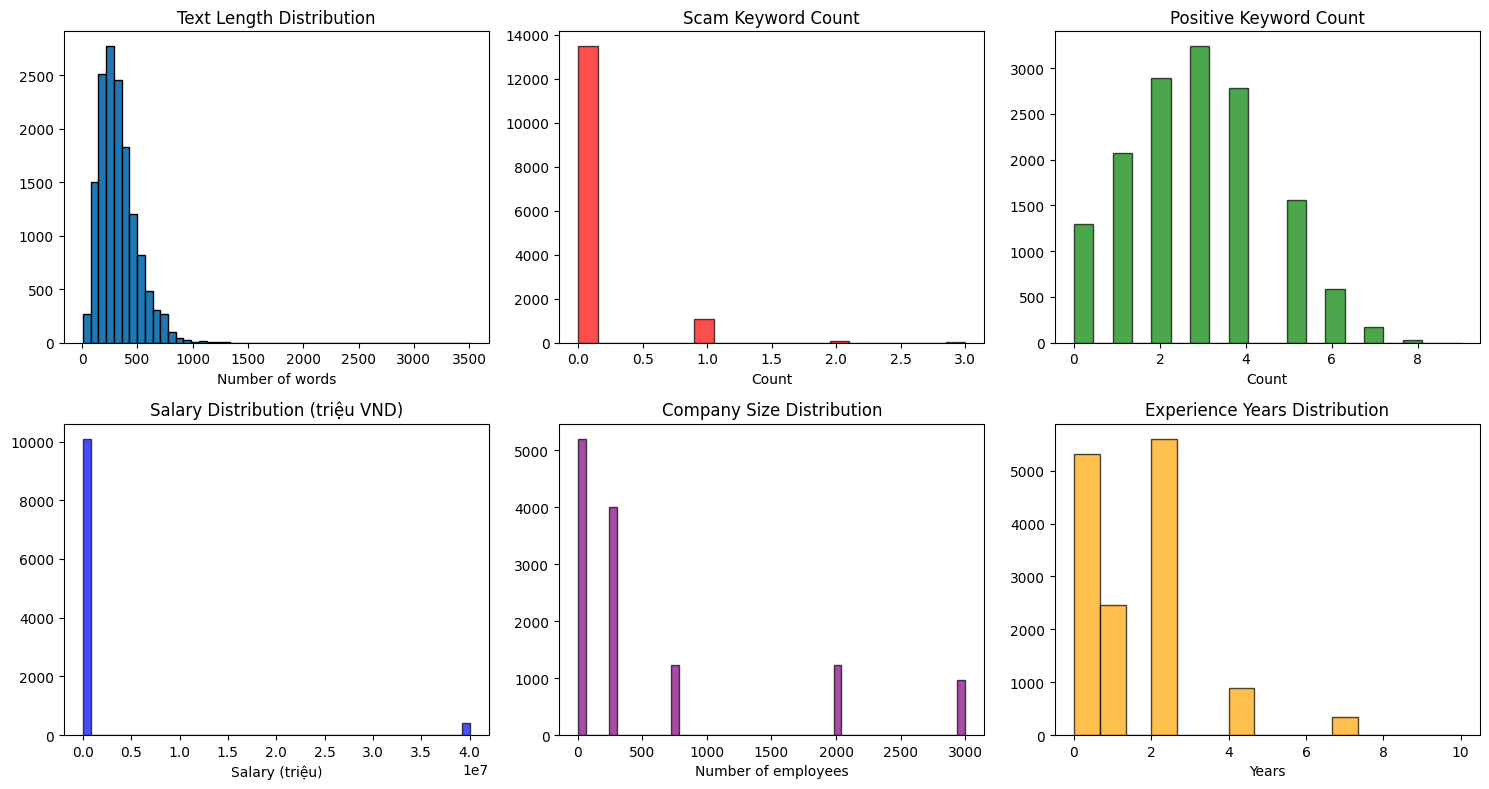

In [8]:
# Visualize phân bố một số features quan trọng
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1. Text length
axes[0, 0].hist(features_df['text_length'], bins=50, edgecolor='black')
axes[0, 0].set_title('Text Length Distribution')
axes[0, 0].set_xlabel('Number of words')

# 2. Scam keyword count
axes[0, 1].hist(features_df['scam_keyword_count'], bins=20, edgecolor='black', color='red', alpha=0.7)
axes[0, 1].set_title('Scam Keyword Count')
axes[0, 1].set_xlabel('Count')

# 3. Positive keyword count
axes[0, 2].hist(features_df['positive_keyword_count'], bins=20, edgecolor='black', color='green', alpha=0.7)
axes[0, 2].set_title('Positive Keyword Count')
axes[0, 2].set_xlabel('Count')

# 4. Salary average
salary_nonzero = features_df[features_df['salary_avg'] > 0]['salary_avg']
axes[1, 0].hist(salary_nonzero / 1000000, bins=50, edgecolor='black', color='blue', alpha=0.7)
axes[1, 0].set_title('Salary Distribution (triệu VND)')
axes[1, 0].set_xlabel('Salary (triệu)')

# 5. Company size
company_size_nonzero = features_df[features_df['company_size_value'] > 0]['company_size_value']
axes[1, 1].hist(company_size_nonzero, bins=50, edgecolor='black', color='purple', alpha=0.7)
axes[1, 1].set_title('Company Size Distribution')
axes[1, 1].set_xlabel('Number of employees')

# 6. Experience years
axes[1, 2].hist(features_df['experience_years'], bins=15, edgecolor='black', color='orange', alpha=0.7)
axes[1, 2].set_title('Experience Years Distribution')
axes[1, 2].set_xlabel('Years')

plt.tight_layout()
plt.show()

## 🔗 Ghép với dữ liệu gốc

In [9]:
# Ghép features với data gốc
df_enhanced = pd.concat([df, features_df], axis=1)

print(f"📊 Enhanced DataFrame shape: {df_enhanced.shape}")
print(f"\n📋 Total columns: {len(df_enhanced.columns)}")
print(f"   - Original columns: {len(df.columns)}")
print(f"   - New features: {len(features_df.columns)}")

df_enhanced.head()

📊 Enhanced DataFrame shape: (14634, 38)

📋 Total columns: 38
   - Original columns: 10
   - New features: 28


,FULL_TEXT,Job Title,Company Overview,Job Description,Job Requirements,Benefits,Company Size,Years of Experience,Number Cadidate,Salary,...,company_size_value,is_small_company,company_overview_length,company_overview_missing,no_experience_required,experience_years,num_candidates,mass_recruitment,requirements_length,requirements_missing
0,sale admin website dhc việt nam trực_thuộc côn...,sale admin website,dhc việt nam trực_thuộc công_ty cp belie nhà p...,thường_xuyên cập_nhật các thay_đổi liên_quan t...,1 học_vấn kiến_thức và trình_độ chuyên_môn tốt...,được xét_duyệt đánh_giá định_kỳ 2 lần năm làm_...,100-499,1-3 năm,1,"5,000,000 - 10,000,000",...,299,0,939,0,0,2,1,0,64,0
1,thực_tập_sinh lập_trình no code low code platf...,thực_tập_sinh lập_trình no code low code platform,thành_viên thuộc tập_đoàn g group công_ty cổ_p...,phối_hợp với bộ_phận lập_trình no code low cod...,sinh_viên năm 3 năm 4 hoặc sinh_viên cao_học n...,làm_việc trong môi_trường văn_hóa nhật bản chu...,100-499,Không yêu cầu kinh nghiệm,2,"1,000,000 - 5,000,000",...,299,0,864,0,1,0,2,0,61,0
2,hr business partner công_ty_tnhh melody logist...,hr business partner,công_ty_tnhh melody logistics được biết đến là...,xây_dựng và thực_hiện chiến_lược nhân_sự phù_h...,tốt_nghiệp đại_học các chuyên_ngành liên_quan ...,lương thỏa_thuận theo năng_lực làm_việc trong ...,100-499,5-10 năm,1,Thỏa thuận,...,299,0,1117,0,0,7,1,0,74,0
3,general manager khách_sạn danaciti by dabi là ...,general manager,khách_sạn danaciti by dabi là khách_sạn 4 sao ...,1 lập và triển_khai kế_hoạch kinh_doanh định_k...,tốt_nghiệp đại_học trở lên chuyên_ngành quản_t...,tiền_lương thưởng và các khoản trợ_cấp khác sẽ...,25-99,3-5 năm,1,Thỏa thuận,...,62,0,152,0,0,4,1,0,65,0
4,lê tân gymasaster quâ n 12 công_ty_tnhh tm xnk...,lê tân gymasaster quâ n 12,công_ty_tnhh tm xnk nguô n sô ng viê t cung câ...,trực quầy lễ_tân tư_vấn bán hàng gói membershi...,giới_tính ưu_tiên_nữ từ 22 35 tuổi kinh_nghiệm...,thu_nhập lương cơ_bản thưởng kpis hoa_hồng các...,100-499,Không yêu cầu kinh nghiệm,2,"5,000,000 - 10,000,000",...,299,0,256,0,1,0,2,0,58,0


## 💾 Lưu kết quả

In [10]:
# Lưu file
output_file = "../data/JOB_DATA_ENHANCED_FEATURES.csv"

df_enhanced.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print(f"💾 Đã lưu file: {output_file}")
print(f"📊 Shape: {df_enhanced.shape}")
print(f"📁 File size: {df_enhanced.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

print("\n✅ Part 2 hoàn thành!")
print("\n➡️ Tiếp theo: Part 3 - Multi-method Labeling")

💾 Đã lưu file: ../data/JOB_DATA_ENHANCED_FEATURES.csv
📊 Shape: (14634, 38)
📁 File size: 128.86 MB

✅ Part 2 hoàn thành!

➡️ Tiếp theo: Part 3 - Multi-method Labeling


---

## ✅ Checkpoint 2: Hoàn thành Feature Engineering

**Đã làm:**
- ✅ Định nghĩa AdvancedFeatureExtractor class
- ✅ Trích xuất Text Features (10+)
- ✅ Trích xuất Salary Features (6+)
- ✅ Trích xuất Company Features (5+)
- ✅ Trích xuất Requirement Features (6+)
- ✅ Tổng cộng: **30+ features**
- ✅ Lưu file: `JOB_DATA_ENHANCED_FEATURES.csv`

**Tiếp theo:**
- ➡️ Part 3: Multi-method Labeling (Rule-based + Anomaly Detection)

---